# Lab 7: Distances, resolution and convergence
**Python supplement · Worked solutions · English**

Compute symmetric differences and Hausdorff distances; see exactly what a pixel grid or a point cloud represents.

These two exercises supplement the mathematical lab; they are not
additional required work inside its original 90-minute schedule.
Allow roughly 60–90 minutes, depending on Python experience.

Run the setup cell first, then work from top to bottom. The task functions
are completed in this version. The demonstration cells generate the figures
and run mathematical checks; discussion guidance follows each exercise.

A plot, finite search or successful iteration supplies numerical
evidence. State separately any theorem used to establish existence,
global optimality or an equality case.


This version contains completed code and discussion guidance. All plots and checks can be reproduced with **Restart Kernel and Run All**.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.25,
                     'figure.constrained_layout.use': True})

def closed(v):
    """Repeat the first vertex only for plotting."""
    return np.vstack([v, v[0]])

def area(v):
    """Unsigned shoelace area of an ordered simple polygon."""
    return abs(np.sum(v[:, 0]*np.roll(v[:, 1], -1)
                      - v[:, 1]*np.roll(v[:, 0], -1)))/2

def perimeter(v):
    return np.linalg.norm(np.roll(v, -1, axis=0)-v, axis=1).sum()

def outline(ax, v, **kwargs):
    p = closed(v)
    ax.plot(p[:, 0], p[:, 1], **kwargs)
    ax.set_aspect('equal', adjustable='box')

from scipy.spatial import cKDTree


## Exercise 7.1: A thin extension can disappear from a raster

Let $S=[0,1]^2$ and $K_n=S\cup([1,2]\times[0,1/n])$.
Exactly, $d_1(K_n,S)=1/n$ whereas $d_H(K_n,S)=1$.

**Code tasks (30–40 minutes).**
1. Complete `raster_distance(n, resolution)` using a pixel-center grid on
   $[0,2]\times[0,1]$, with `2*resolution` columns and `resolution` rows.
   Each pixel has area `1/resolution**2`.
2. Evaluate membership in both shapes, use `np.logical_xor` for the
   symmetric difference, and sum pixel areas.
3. Compare resolutions 32, 64 and 256 for $n=2,4,\ldots,512$.
   Plot relative estimates and display one raster of the added strip.

**Return contract:** `(estimated_distance, difference_mask)`; the Boolean
mask has shape `(resolution, 2*resolution)`. Use midpoint coordinates,
not grid vertices. Record zeros explicitly: a zero raster estimate need
not mean equality almost everywhere of the original shapes.


In [2]:
def raster_distance(n, resolution):
    x=(np.arange(2*resolution)+.5)/resolution
    y=(np.arange(resolution)+.5)/resolution
    X,Y=np.meshgrid(x,y)
    square=(X <= 1)
    extension=(X >= 1)&(Y <= 1/n)
    difference=np.logical_xor(square,square|extension)
    return difference.sum()/resolution**2,difference


**Run, visualize and check.** Adapt these plots as requested, and report what changes when you refine the discretization or vary parameters.

 32 rows: invisible strips at n=[128, 256, 512]
 64 rows: invisible strips at n=[256, 512]
256 rows: invisible strips at n=[]


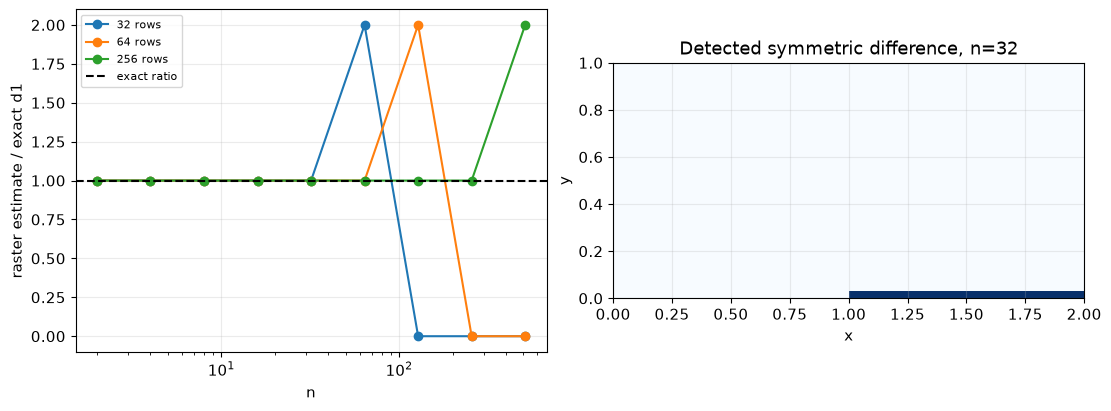

The exact Hausdorff distance stays 1 for every n.


In [3]:
result=raster_distance(8,64)
if result is None:
    print('Complete raster_distance, then rerun this cell.')
else:
    ns=2**np.arange(1,10)
    fig,ax=plt.subplots(1,2,figsize=(11,4))
    for resolution in (32,64,256):
        estimates=np.array([raster_distance(n,resolution)[0] for n in ns])
        ax[0].semilogx(ns,estimates*ns,'o-',label=f'{resolution} rows')
        print(f'{resolution:3d} rows: invisible strips at n={ns[estimates == 0].tolist()}')
    ax[0].axhline(1,color='black',ls='--',label='exact ratio')
    ax[0].set(xlabel='n',ylabel='raster estimate / exact d1'); ax[0].legend(fontsize=8)
    _,mask=raster_distance(32,64)
    ax[1].imshow(mask,origin='lower',extent=(0,2,0,1),interpolation='nearest',cmap='Blues')
    ax[1].set(title='Detected symmetric difference, n=32',xlabel='x',ylabel='y')
    plt.show()
    np.testing.assert_allclose(raster_distance(8,64)[0],1/8)
    assert raster_distance(512,32)[0] == 0
    print('The exact Hausdorff distance stays 1 for every n.')


**Explain your observations.** Why can area convergence coexist with a distant tip? Why must image resolution change when a geometric feature gets thinner?

**Solution guidance:** The extension reaches a fixed distance but has vanishing area. A feature thinner than the spacing of sample centers can be missed altogether. The raster describes a pixel approximation; zero estimated difference does not imply equality of the original measurable sets.

## Exercise 7.2: Hausdorff distance through nearest neighbors

For **finite nonempty point clouds**, compute
$\rho(K,L)=\max_{x\in K}\min_{y\in L}|x-y|$ and
$d_H(K,L)=\max(\rho(K,L),\rho(L,K))$.
Use `cKDTree(L).query(K, k=1)[0]` for distances from points of $K$ to $L$.

**Code tasks (35–45 minutes).**
1. Complete `cloud_distance(K,L)`, returning both directed excesses and their maximum.
2. Compare $G_n=\{(i/n,j/n)\}$ with a denser grid $G_{128}$, for
   $n=2,4,8,16,32$. Compare with the exact continuous-square distance
   $d_H(G_n,[0,1]^2)=\sqrt2/(2n)$.
3. Visualize the two distance functions and check their supremum difference.
   Evaluate on a set **containing both clouds** to recover the exact
   finite-cloud Hausdorff distance; a sparse unrelated probe mesh can miss it.

**Return contract:** `(rho_KL, rho_LK, dH)`. Reject empty clouds with
`ValueError`. Every finite grid has planar area zero: a dense cloud's
Hausdorff convergence to the square does not imply area convergence.
For these particular nested grids, the fine grid includes the coarse-cell
centers, so the sampled distance also equals the known continuous distance.


**Provided helper code.** Run this cell before implementing the task.

In [4]:
def square_grid(n):
    t=np.linspace(0,1,n+1)
    X,Y=np.meshgrid(t,t)
    return np.column_stack([X.ravel(),Y.ravel()])


In [5]:
def cloud_distance(K,L):
    if len(K)==0 or len(L)==0:
        raise ValueError('Hausdorff distance here requires nonempty clouds.')
    rho_KL=cKDTree(L).query(K,k=1)[0].max()
    rho_LK=cKDTree(K).query(L,k=1)[0].max()
    return rho_KL,rho_LK,max(rho_KL,rho_LK)


**Run, visualize and check.** Adapt these plots as requested, and report what changes when you refine the discretization or vary parameters.

n= 2: excesses=(0.000000,0.353553), dH=0.353553
n= 4: excesses=(0.000000,0.176777), dH=0.176777
n= 8: excesses=(0.000000,0.088388), dH=0.088388
n=16: excesses=(0.000000,0.044194), dH=0.044194
n=32: excesses=(0.000000,0.022097), dH=0.022097
Supremum on coarse points alone: 0.0


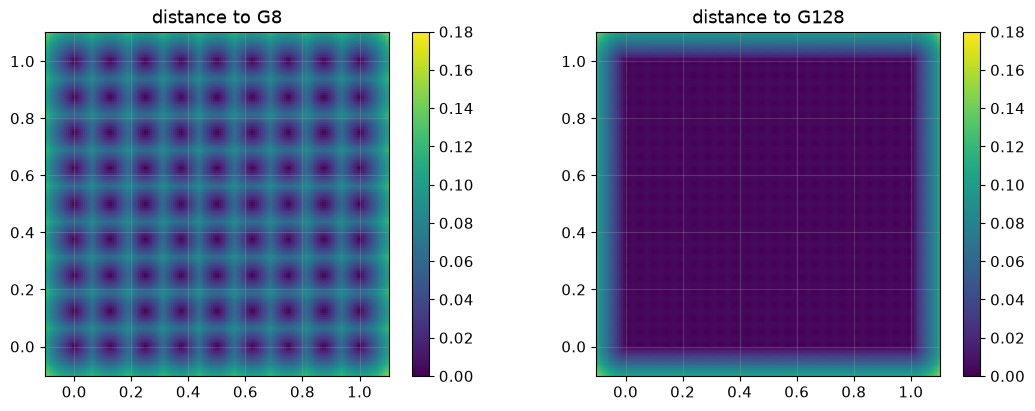

Empty-cloud check passed.


In [6]:
fine=square_grid(128)
result=cloud_distance(square_grid(8),fine)
if result is None:
    print('Complete cloud_distance, then rerun this cell.')
else:
    for n in (2,4,8,16,32):
        coarse=square_grid(n)
        forward,backward,dH=cloud_distance(coarse,fine)
        exact=np.sqrt(2)/(2*n)
        np.testing.assert_allclose(dH,exact,atol=1e-12)
        np.testing.assert_allclose(forward,0.,atol=1e-12)
        print(f'n={n:2d}: excesses=({forward:.6f},{backward:.6f}), dH={dH:.6f}')
    coarse=square_grid(8)
    evaluation=np.vstack([fine,coarse])
    dK=cKDTree(coarse).query(evaluation)[0]
    dL=cKDTree(fine).query(evaluation)[0]
    np.testing.assert_allclose(np.max(abs(dK-dL)),cloud_distance(coarse,fine)[2])
    # A probe set consisting only of coarse points would incorrectly give zero.
    sparse_difference=np.max(abs(cKDTree(coarse).query(coarse)[0]-cKDTree(fine).query(coarse)[0]))
    print('Supremum on coarse points alone:',sparse_difference)
    axis=np.linspace(-.1,1.1,180)
    X,Y=np.meshgrid(axis,axis); probes=np.column_stack([X.ravel(),Y.ravel()])
    fig,axes=plt.subplots(1,2,figsize=(11,4))
    for ax,cloud,title in zip(axes,[coarse,fine],['distance to G8','distance to G128']):
        Z=cKDTree(cloud).query(probes)[0].reshape(X.shape)
        im=ax.pcolormesh(X,Y,Z,shading='auto',vmin=0,vmax=.18)
        ax.set_aspect('equal'); ax.set_title(title); fig.colorbar(im,ax=ax)
    plt.show()
    np.testing.assert_allclose(cloud_distance(coarse,coarse)[2],0.)
    np.testing.assert_allclose(cloud_distance(fine,coarse)[2],cloud_distance(coarse,fine)[2])
    try:
        cloud_distance(np.empty((0,2)),fine)
    except ValueError:
        print('Empty-cloud check passed.')
    else:
        raise AssertionError('Empty clouds must be rejected.')


**Explain your observations.** Does your code measure distance between filled regions, their boundaries or their sampled points? How does the distance-function identity help prove Blaschke selection?

**Solution guidance:** The code measures finite point sets, not filled cells. Their planar areas are all zero. In this specially aligned example the exact square distance is also attained on the fine grid. The distance-function identity turns uniform function convergence into Hausdorff convergence, after proving the limiting function is a distance function.

**Before submitting:** restart the kernel, run all cells in order, check axis labels and units, and explain any discrepancy between numerical and exact quantities.